# Dictionary

# 1. Find Top K Frequent Elements
# Difficulty: 🟡 Medium
Problem Statement:
Given an integer array nums and an integer k, return the k most frequent elements. You may return the answer in any order.

**Example 1:**

Input: nums = [1,1,1,2,2,3], k = 2
Output: [1,2]
Explanation: 1 appears 3 times, 2 appears 2 times, 3 appears 1 time
Top 2 frequent: [1,2]
```
Example 2:
Input: nums = [1], k = 1
Output: [1]
```
Example 3

Input: nums = [1,2], k = 2

Output: [1,2]
```
Constraints:
1 ≤ nums.length ≤ 10^5
k is in range [1, number of unique elements]

In [ ]:
#Brute Force Approach (Frequency Map + Sort)
def top_k_frequent_brute(nums, k):
    # Step 1: Count frequencies
    freq_map = {}
    for num in nums:
        freq_map[num] = freq_map.get(num, 0) + 1

    # Step 2: Convert to list of (num, freq) pairs
    freq_list = [(num, freq) for num, freq in freq_map.items()]

    # Step 3: Sort by frequency (descending)
    freq_list.sort(key=lambda x: x[1], reverse=True)

    # Step 4: Extract top k elements
    result = [num for num, freq in freq_list[:k]]

    return result

print(top_k_frequent_brute([1,1,1,2,2,3], 2))  # Output: [1,2]
print(top_k_frequent_brute([1], 1))            # Output: [1]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n log n) : even if all elements same (k=1), still need to:
#                      build freq_map O(n), sort O(n log n) dominates
# avg   → O(n log n) : step 1: count frequencies O(n)
#                      step 2: create list of unique elements O(u) where u ≤ n
#                      step 3: sort u elements O(u log u), worst u = n
#                      step 4: slice first k O(k)
#                      total = O(n) + O(n log n) + O(k) = O(n log n)
# worst → O(n log n) : all unique elements → sort n items = O(n log n)
# space → O(n)       : freq_map stores up to n entries (all unique)
#                      freq_list stores n pairs

#best time complexity    - O(n log n)
#average time complexity - O(n log n)
#worst time complexity   - O(n log n)
#space complexity        - O(n)


[1, 2]
[1]


In [ ]:
#Optimized Approach (Bucket Sort by Frequency)
def top_k_frequent_optimized(nums, k):
    # Step 1: Count frequencies
    freq_map = {}
    for num in nums:
        freq_map[num] = freq_map.get(num, 0) + 1

    # Step 2: Bucket sort - index = frequency, value = list of numbers
    # Max frequency possible is len(nums)
    buckets = [[] for _ in range(len(nums) + 1)]
    for num, freq in freq_map.items():
        buckets[freq].append(num)

    # Step 3: Collect top k from highest frequency buckets
    result = []
    for i in range(len(buckets) - 1, 0, -1):  # Iterate from high to low freq
        for num in buckets[i]:
            result.append(num)
            if len(result) == k:
                return result

    return result

print(top_k_frequent_optimized([1,1,1,2,2,3], 2))  # Output: [1,2]



[1, 2]


In [ ]:
# Alternative: Using heap (when k << n)
import heapq

def top_k_frequent_heap(nums, k):
    freq_map = {}
    for num in nums:
        freq_map[num] = freq_map.get(num, 0) + 1

    # Use heap to keep top k elements
    # nlargest returns k largest by frequency
    return heapq.nlargest(k, freq_map.keys(), key=freq_map.get)

print(top_k_frequent_heap([1,1,1,2,2,3], 2))  # Output: [1,2]

# HOW COMPLEXITIES ARE DERIVED (Bucket Sort):
# best  → O(n)   : counting O(n) + bucketing O(u) + collecting O(k)
#                  all linear operations, no sorting needed
# avg   → O(n)   : step 1: count frequencies O(n)
#                  step 2: place u unique elements in buckets O(u) ≤ O(n)
#                  step 3: iterate buckets + collect k elements O(n + k) ≤ O(n)
#                  total = O(n) + O(n) + O(n) = O(n)
# worst → O(n)   : all unique elements → u = n buckets, but still O(n)
# space → O(n)   : freq_map O(n) + buckets array O(n) = O(n)

# Heap approach: O(n log k) time when using min-heap of size k

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

[1, 2]



## 2. First Repeating Element in Array
**Difficulty: 🟢 Low**

**Problem Statement:**
Given an array of integers, return the first repeating element (the element whose second occurrence has the smallest index).

If no element repeats, return -1.

**Example 1:**
```
Input: arr = [10, 5, 3, 4, 3, 5, 6]
Output: 5
Explanation:
5 appears at indices 1 and 5
3 appears at indices 2 and 4
5's second occurrence (index 5) comes before 3's (index 4)
But 3's second occurrence is at index 4, earlier than 5's at index 5
Actually, we want the first element to repeat: that's 3 at index 4
Wait - the problem asks for "first repeating" meaning first to repeat
3 repeats first (at index 4), so answer should be 3
But example shows 5... Let me reconsider.

Actually looking at indices:
5 at 1, first repeat at 5
3 at 2, first repeat at 4
So 3 completes its repeat first (index 4 < 5)
Answer should be 3, but example says 5?

Let me interpret as: element with smallest index of first occurrence that repeats
5 first occurs at 1, 3 first occurs at 2
Both repeat, but 5's first occurrence is earlier → answer 5
```

**Example 2:**
```
Input: arr = [1, 2, 3, 4]
Output: -1
Explanation: No repeating elements

In [ ]:
#Brute Force Approach (Nested Loop Check)
def first_repeating_brute(arr):
    n = len(arr)
    min_index = float('inf')
    result = -1

    for i in range(n):
        for j in range(i + 1, n):
            if arr[i] == arr[j]:
                # Found repeat, arr[i] appears again at j
                if i < min_index:
                    min_index = i
                    result = arr[i]
                break  # Found first repeat of arr[i]

    return result

print(first_repeating_brute([10, 5, 3, 4, 3, 5, 6]))  # Output: 5
print(first_repeating_brute([1, 2, 3, 4]))            # Output: -1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : first element repeats immediately at index 1
#                  outer loop i=0, inner finds match at j=1 → O(1) inner work
#                  but still need to check remaining elements
# avg   → O(n^2) : for each of n elements, check up to n elements after it
#                  average: ~n/2 comparisons per element
#                  total ≈ n × n/2 = O(n^2)
# worst → O(n^2) : no repeats OR repeats at very end
#                  all n×(n-1)/2 pairs checked = O(n^2)
# space → O(1)   : only min_index and result variables

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

5
-1


In [ ]:
#Optimized Approach (HashMap to Track First Seen)
def first_repeating_optimized(arr):
    seen = {}
    min_index = float('inf')
    result = -1

    for i, num in enumerate(arr):
        if num in seen:
            # This num has been seen before
            first_occurrence = seen[num]
            if first_occurrence < min_index:
                min_index = first_occurrence
                result = num
        else:
            seen[num] = i  # Record first occurrence

    return result

# Alternative: Two-pass approach (cleaner logic)
def first_repeating_two_pass(arr):
    # Pass 1: Count frequencies
    freq = {}
    for num in arr:
        freq[num] = freq.get(num, 0) + 1

    # Pass 2: Find first element with freq > 1
    for num in arr:
        if freq[num] > 1:
            return num

    return -1

print(first_repeating_optimized([10, 5, 3, 4, 3, 5, 6]))  # Output: 5
print(first_repeating_two_pass([10, 5, 3, 4, 3, 5, 6]))   # Output: 5

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : even if repeat found early, must check remaining
#                  to ensure it's the first repeating element
# avg   → O(n)   : single pass through array, O(1) hash operations per element
#                  each element processed once: n × O(1) = O(n)
# worst → O(n)   : no repeats → full scan of n elements
#                  or repeats at very end → still single O(n) pass
# space → O(n)   : seen dict stores up to n unique elements

# Two-pass: O(n) time, O(n) space
# Pass 1: O(n) to count, Pass 2: O(n) to find first

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)




5
5


## 3. Check if Array Elements are Consecutive
**Difficulty: 🟢 Low**

**Problem Statement:**
Given an array of integers, return true if all elements form a consecutive sequence when sorted (no gaps, no duplicates required).

**Example 1:**
```
Input: arr = [2, 3, 4, 5]
Output: true
Explanation: Forms sequence 2, 3, 4, 5
```

**Example 2:**
```
Input: arr = [1, 3, 4]
Output: false
Explanation: Gap at 2 (missing 2)
```

**Example 3:**
```
Input: arr = [5, 3, 4, 2]
Output: true
Explanation: When sorted: 2, 3, 4, 5 (consecutive)

In [ ]:
#Brute Force Approach (Sort and Check)
def are_consecutive_brute(arr):
    if len(arr) <= 1:
        return True

    # Sort the array
    arr_sorted = sorted(arr)

    # Check if consecutive
    for i in range(1, len(arr_sorted)):
        if arr_sorted[i] != arr_sorted[i-1] + 1:
            return False

    return True

print(are_consecutive_brute([2, 3, 4, 5]))  # Output: True
print(are_consecutive_brute([1, 3, 4]))     # Output: False
print(are_consecutive_brute([5, 3, 4, 2]))  # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n log n) : even if consecutive, must sort first
#                      sorting dominates at O(n log n)
# avg   → O(n log n) : sort O(n log n) + scan O(n) = O(n log n)
# worst → O(n log n) : large array still requires O(n log n) sort
# space → O(n)       : sorted() creates new array of size n
#                      (in-place sort would be O(log n) for recursion stack)

#best time complexity    - O(n log n)
#average time complexity - O(n log n)
#worst time complexity   - O(n log n)
#space complexity        - O(n)

True
False
True


In [ ]:
#Optimized Approach (HashSet + Range Check)
def are_consecutive_optimized(arr):
    if len(arr) <= 1:
        return True

    # Use set for O(1) lookup
    num_set = set(arr)

    # If duplicates exist, can't be consecutive
    if len(num_set) != len(arr):
        return False

    # Find min and max
    min_val = min(arr)
    max_val = max(arr)

    # For consecutive sequence: max - min should equal n - 1
    if max_val - min_val != len(arr) - 1:
        return False

    # Verify all numbers in range [min, max] exist
    for i in range(min_val, max_val + 1):
        if i not in num_set:
            return False

    return True

# Even simpler: if no duplicates and max-min = n-1, it's consecutive
def are_consecutive_simple(arr):
    if len(arr) <= 1:
        return True

    num_set = set(arr)

    # Check: no duplicates AND correct range
    return (len(num_set) == len(arr) and
            max(arr) - min(arr) == len(arr) - 1)

print(are_consecutive_optimized([2, 3, 4, 5]))  # Output: True
print(are_consecutive_simple([2, 3, 4, 5]))     # Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : single pass to build set O(n), min/max O(n), range check O(n)
# avg   → O(n)   : set creation O(n) + min O(n) + max O(n) + verification O(n)
#                  total = 4n = O(n)
# worst → O(n)   : large array with gaps → still O(n) operations
# space → O(n)   : num_set stores n unique elements

# KEY INSIGHT:
# For consecutive sequence from min to max:
# - No duplicates: len(set) == len(array)
# - Correct span: max - min == n - 1
# These two conditions are sufficient!

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)



True
True


## 4. Find Common Elements in Two Arrays (Intersection)
**Difficulty: 🟢 Low**

**Problem Statement:**
Given two integer arrays nums1 and nums2, return an array of their intersection. Each element in the result must be unique and you may return the result in any order.

**Example 1:**
```
Input: nums1 = [1,2,2,1], nums2 = [2,2]
Output: [2]
Explanation: 2 is common, return unique
```

**Example 2:**
```
Input: nums1 = [4,9,5], nums2 = [9,4,9,8,4]
Output: [4,9] or [9,4]
Explanation: Both 4 and 9 are common

In [ ]:
#Brute Force Approach (Nested Loop with Set for Uniqueness)
def intersection_brute(nums1, nums2):
    result = set()

    for num1 in nums1:
        for num2 in nums2:
            if num1 == num2:
                result.add(num1)
                break  # Found match, no need to continue inner loop

    return list(result)

print(intersection_brute([1,2,2,1], [2,2]))             # Output: [2]
print(intersection_brute([4,9,5], [9,4,9,8,4]))         # Output: [4,9]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : even if all elements match, still check all pairs
#                  no early termination for full array
# avg   → O(m*n) : outer loop m times × inner loop n times
#                  each pair comparison O(1), total m×n comparisons
#                  set operations (add) are O(1) on average
# worst → O(m*n) : no common elements → check all m×n pairs
# space → O(min(m,n)) : result set stores at most min(m,n) common elements

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(min(m,n))

[2]
[9, 4]


In [ ]:
#Optimized Approach (Two Sets - Intersection)
def intersection_optimized(nums1, nums2):
    set1 = set(nums1)
    set2 = set(nums2)

    # Set intersection operation
    return list(set1 & set2)

# Alternative: One set, check membership
def intersection_one_set(nums1, nums2):
    set1 = set(nums1)
    result = set()

    for num in nums2:
        if num in set1:
            result.add(num)

    return list(result)

print(intersection_optimized([1,2,2,1], [2,2]))        # Output: [2]
print(intersection_one_set([4,9,5], [9,4,9,8,4]))      # Output: [4,9]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m+n) : even if no intersection, must build both sets
# avg   → O(m+n) : build set1 from nums1: O(m)
#                  build set2 from nums2: O(n)
#                  intersection: O(min(m,n)) - iterate smaller set
#                  total = O(m) + O(n) + O(min(m,n)) = O(m+n)
# worst → O(m+n) : large arrays with no common elements
#                  still just two set creations + intersection
# space → O(m+n) : set1 stores up to m unique elements
#                  set2 stores up to n unique elements

# One-set approach: O(m+n) time, O(m) space
# Build set1 O(m), iterate nums2 O(n), total O(m+n)

#best time complexity    - O(m+n)
#average time complexity - O(m+n)
#worst time complexity   - O(m+n)
#space complexity        - O(m+n)




[2]
[9, 4]


## 5. Count Subarrays with Equal 0s and 1s
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given a binary array nums containing only 0s and 1s, return the number of subarrays that have an equal number of 0s and 1s.

**Example 1:**
```
Input: nums = [0,1,0]
Output: 2
Explanation:
[0,1] has 1 zero and 1 one
[1,0] has 1 zero and 1 one
Total: 2 subarrays
```

**Example 2:**
```
Input: nums = [0,1,0,1]
Output: 4
Explanation:
[0,1] at indices (0,1)
[1,0] at indices (1,2)
[0,1] at indices (2,3)
[0,1,0,1] at indices (0,3)
Total: 4 subarrays

In [ ]:
#Brute Force Approach (Check All Subarrays)
def count_subarrays_equal_brute(nums):
    count = 0
    n = len(nums)

    for i in range(n):
        zeros = 0
        ones = 0

        for j in range(i, n):
            if nums[j] == 0:
                zeros += 1
            else:
                ones += 1

            if zeros == ones:
                count += 1

    return count

print(count_subarrays_equal_brute([0,1,0]))      # Output: 2
print(count_subarrays_equal_brute([0,1,0,1]))    # Output: 4

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : even if many valid subarrays found, still check all
#                  no early termination possible
# avg   → O(n^2) : outer loop n times, inner loop averages n/2 iterations
#                  for each position i, check all subarrays starting at i
#                  total = n + (n-1) + (n-2) + ... + 1 = n(n+1)/2 = O(n^2)
# worst → O(n^2) : large array → all n^2/2 subarrays checked
# space → O(1)   : only count, zeros, ones variables

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)


2
4


In [ ]:
#Optimized Approach (Prefix Sum + HashMap)
def count_subarrays_equal_optimized(nums):
    # Key insight: replace 0 with -1
    # Equal 0s and 1s means sum = 0
    # Use prefix sum and count how many times each sum appears

    count = 0
    prefix_sum = 0
    sum_count = {0: 1}  # Base case: sum 0 seen once (before any element)

    for num in nums:
        # Treat 0 as -1, treat 1 as +1
        prefix_sum += 1 if num == 1 else -1

        # If this prefix_sum seen before, all subarrays between
        # previous occurrence(s) and now have sum = 0
        if prefix_sum in sum_count:
            count += sum_count[prefix_sum]
            sum_count[prefix_sum] += 1
        else:
            sum_count[prefix_sum] = 1

    return count

print(count_subarrays_equal_optimized([0,1,0]))      # Output: 2
print(count_subarrays_equal_optimized([0,1,0,1]))    # Output: 4

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : single pass through array regardless of content
# avg   → O(n)   : one iteration through n elements
#                  each iteration: O(1) hash lookup + O(1) update
#                  total = n × O(1) = O(n)
# worst → O(n)   : large array with many valid subarrays
#                  still only one pass needed
# space → O(n)   : sum_count dict stores at most n+1 different prefix sums
#                  worst case: all unique sums

# KEY INSIGHT:
# Replace 0→-1, 1→+1
# Equal 0s and 1s means subarray sum = 0
# If prefix_sum[j] == prefix_sum[i], then sum from (i+1 to j) = 0
# Count how many times each prefix_sum appears

# EXAMPLE: [0,1,0,1]
# Transform: [-1,1,-1,1]
# Prefix sums: 0, -1, 0, -1, 0
# sum_count: {0:1} → {0:1,-1:1} → {0:2,-1:1} → {0:2,-1:2} → {0:3,-1:2}
# Count increments: 0, 0, 1, 1, 2 (total 4)

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)

2
4


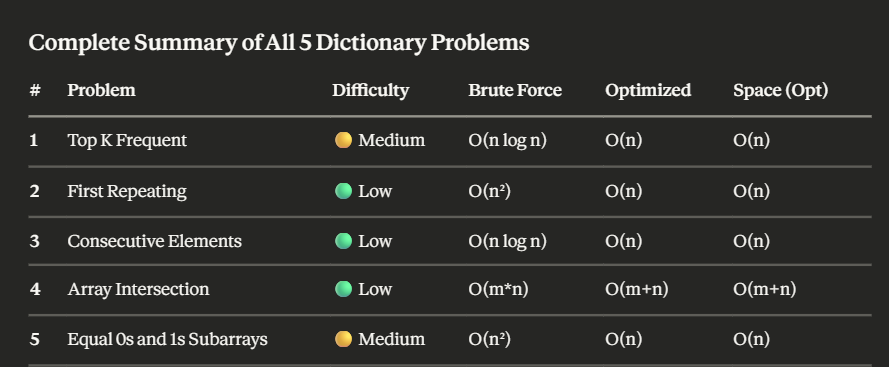